In [28]:
import zipfile

zip_path = "/content/archive (4).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [29]:
import os

os.listdir("/content")

['.config', 'archive (4).zip', 'mnist_png', 'sample_data']

In [30]:
import os

print(os.listdir("/content/mnist_png"))

['testing', 'training']


In [31]:
print(os.listdir("/content/mnist_png/training"))


['2', '7', '4', '5', '3', '6', '8', '9', '0', '1']


In [32]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(root='/content/mnist_png/training', transform=transform)
test_data = datasets.ImageFolder(root='/content/mnist_png/testing', transform=transform)

print(len(train_data), len(test_data))

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

image, label = train_data[0]
print(image.shape, image.min().item(), image.max().item(), label)

60000 10000
torch.Size([1, 28, 28]) 0.0 1.0 0


In [33]:
def add_noise(images, noise_factor=0.5):
    noisy = images + noise_factor * torch.randn_like(images)
    noisy = torch.clamp(noisy, 0.0, 1.0)
    return noisy

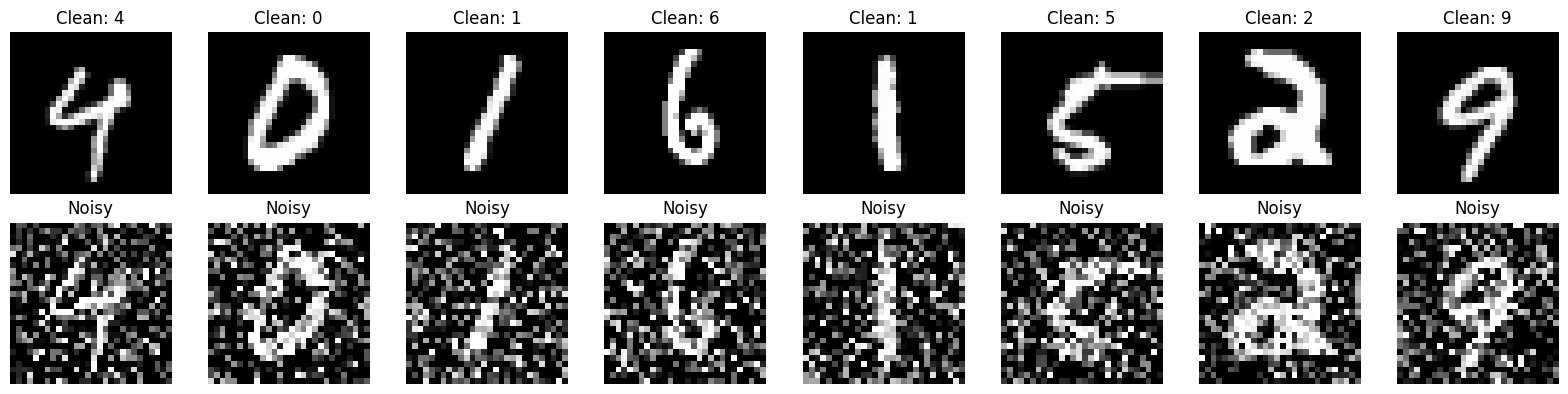

In [34]:
images, labels = next(iter(train_loader))
noisy_images = add_noise(images, noise_factor=0.5)

n = 8

fig, axes = plt.subplots(2, n, figsize=(2*n, 4))

for i in range(n):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f'Clean: {labels[i].item()}')
    axes[0, i].axis('off')

    axes[1, i].imshow(noisy_images[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Noisy')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

In [35]:
import torch.nn as nn

class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # -> (16, 14, 14)
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> (32, 7, 7)
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (16, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (1, 28, 28)
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DenoisingAutoencoder().to(device)
print(model)
print(device)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)
cpu


In [37]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 10

for epoch in range(num_epochs):
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)
        noisy_images = add_noise(images, noise_factor=0.5).to(device)

        # Forward Pass
        outputs = model(noisy_images)
        loss = criterion(outputs, images)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/10], Loss: 0.0563
Epoch [2/10], Loss: 0.0154
Epoch [3/10], Loss: 0.0147
Epoch [4/10], Loss: 0.0143
Epoch [5/10], Loss: 0.0139
Epoch [6/10], Loss: 0.0137
Epoch [7/10], Loss: 0.0135
Epoch [8/10], Loss: 0.0134
Epoch [9/10], Loss: 0.0133
Epoch [10/10], Loss: 0.0132


In [38]:
model.eval()
with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images = test_images.to(device)
    noisy_test_images = add_noise(test_images, noise_factor=0.5).to(device)
    denoised_images = model(noisy_test_images)


test_images = test_images.cpu()
noisy_test_images = noisy_test_images.cpu()
denoised_images = denoised_images.cpu()

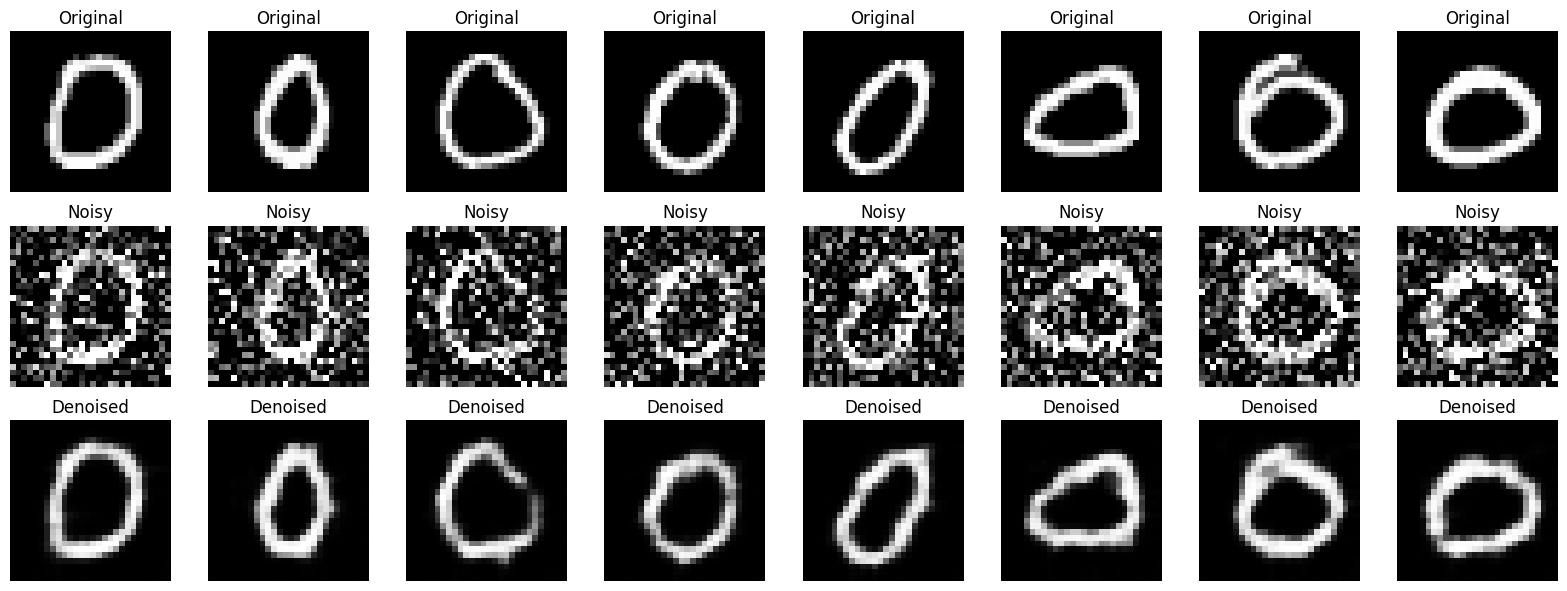

In [39]:
n = 8
fig, axes = plt.subplots(3, n, figsize=(2*n, 6))

for i in range(n):
    axes[0, i].imshow(test_images[i].squeeze(), cmap='gray')
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(noisy_test_images[i].squeeze(), cmap='gray')
    axes[1, i].set_title('Noisy')
    axes[1, i].axis('off')

    axes[2, i].imshow(denoised_images[i].squeeze(), cmap='gray')
    axes[2, i].set_title('Denoised')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

**Observations:**
1. The provided MNIST PNG dataset was successfully loaded.Applied transform.Grayscale to normalize image pixels values from [0,255] to [0,1].
2. Gaussian noise was artificall added to clean images to create noisy input images. used noise factor = 0.5 and used clamp to make sure that the values are in range [0,1].

3. Built a convolutional denoising autoencoder to reconstruct clean images from the noisy input. The convolutional autoencoder uses convolutional neural networks for both the encoder and decoder instead of fully connected dense layers. The encoder gradually reduces the image size from 28 × 28 → 14 × 14 → 7 × 7, while the decoder increases the image size from 7 × 7 → 14 × 14 → 28 × 28.

4. We uses Mean Squared Error(MSE) as a loss funtion to calculate the loss. The mse loss consistently decreased from aprox 0.0563 in the first epoch to 0.0132 after 10 epochs indicating that the model was learning effectively. we used ADAM optimizer with learning rate 0.001.

5. The model successfully removed most of the noise from the input images and was succcesfully in preserving the overall digit. the outputs were visinbly blurry than the original images.

6. From the whole the assignment it can be concluded that convolutional layers are effective for image denoising because they are capable of capturing local spatial features such as edges and strokes. Model generalised well on unseen test images producing outputs that were quite close to the original clean images